## Setup and Paths

In [65]:
import gc
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [66]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Supply_Chain_Demand_Forecasting"
RAW_DIR = f"{PROJECT_DIR}/data/raw"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
NOTEBOOK_DIR = f"{PROJECT_DIR}/notebooks"
MODELS_DIR = f"{PROJECT_DIR}/models"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints/notebook05"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DATA_PATH = f"{PROCESSED_DIR}/feature_engineered_data.csv"
CHECKPOINT_METRICS_PATH = f"{CHECKPOINT_DIR}/ml_model_metrics_checkpoint.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Feature List (defined before load, to restrict usecols)

In [67]:
TARGET = 'units_sold'

FEATURE_COLS = [
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28',
    'rolling_std_7', 'rolling_std_14', 'rolling_std_28',
    'rolling_median_7', 'rolling_median_14', 'rolling_median_28',
    'ema_7', 'ema_14',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'snap', 'has_event', 'snap_lead',
    'sell_price', 'price_rolling_mean_28', 'price_relative', 'price_changed',
]
USE_COLS = ['date', TARGET] + FEATURE_COLS
print(f"Loading {len(USE_COLS)} columns (all features preserved, no reduction).")

Loading 29 columns (all features preserved, no reduction).


## Memory-Efficient Load

In [68]:
int8_cols = ['is_weekend', 'snap', 'has_event', 'price_changed']
float32_cols = [c for c in FEATURE_COLS if c not in int8_cols] + [TARGET]

dtype_map = {c: 'int8' for c in int8_cols}
dtype_map.update({c: 'float32' for c in float32_cols})

CHUNK_SIZE = 2_000_000
chunks = []
for chunk in pd.read_csv(DATA_PATH, usecols=USE_COLS, dtype=dtype_map, parse_dates=['date'], chunksize=CHUNK_SIZE):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

print("Full dataset loaded, no sampling or row reduction:", df.shape)

Full dataset loaded, no sampling or row reduction: (9415478, 29)


## Why Ordinary K-Fold Is Wrong Here

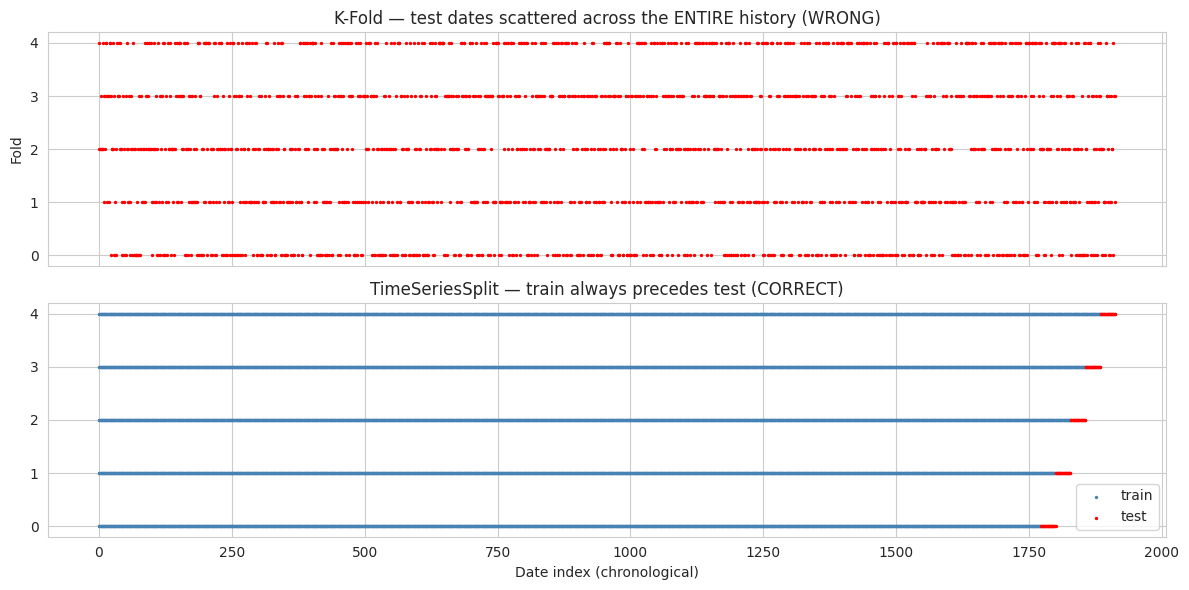

8065

In [70]:
sample_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tscv = TimeSeriesSplit(n_splits=5, test_size=28)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(sample_dates)):
    axes[0].scatter(test_idx, [fold] * len(test_idx), s=2, color='red')
axes[0].set_title('K-Fold — test dates scattered across the ENTIRE history (WRONG)')
axes[0].set_ylabel('Fold')

for fold, (train_idx, test_idx) in enumerate(tscv.split(sample_dates)):
    axes[1].scatter(train_idx, [fold] * len(train_idx), s=2, color='steelblue', label='train' if fold == 0 else "")
    axes[1].scatter(test_idx, [fold] * len(test_idx), s=2, color='red', label='test' if fold == 0 else "")
axes[1].set_title('TimeSeriesSplit — train always precedes test (CORRECT)')
axes[1].set_xlabel('Date index (chronological)')
axes[1].legend()

plt.tight_layout()
plt.show()

del sample_dates
gc.collect()

## Fold Boundaries (computed once, reused everywhere below)

In [71]:
FORECAST_HORIZON = 28
unique_dates = np.sort(df['date'].unique())
tscv = TimeSeriesSplit(n_splits=5, test_size=FORECAST_HORIZON)

fold_boundaries = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_dates)):
    train_end = unique_dates[train_idx[-1]]
    test_start = unique_dates[test_idx[0]]
    test_end = unique_dates[test_idx[-1]]
    fold_boundaries.append((fold, train_end, test_start, test_end))

del unique_dates
gc.collect()

for f in fold_boundaries:
    print(f"Fold {f[0]}: train ends {pd.Timestamp(f[1]).date()} | "
          f"test {pd.Timestamp(f[2]).date()} -> {pd.Timestamp(f[3]).date()}")

Fold 0: train ends 2016-01-03 | test 2016-01-04 -> 2016-01-31
Fold 1: train ends 2016-01-31 | test 2016-02-01 -> 2016-02-28
Fold 2: train ends 2016-02-28 | test 2016-02-29 -> 2016-03-27
Fold 3: train ends 2016-03-27 | test 2016-03-28 -> 2016-04-24
Fold 4: train ends 2016-04-24 | test 2016-04-25 -> 2016-05-22


## Fault-Tolerant, One-Model-at-a-Time Training Loop

In [72]:
def wmape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(actual)

MODEL_FACTORY = {
    'linear_regression': lambda: LinearRegression(),
    'decision_tree': lambda: DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'random_forest': lambda: RandomForestRegressor(
        n_estimators=100, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE
    ),
    'xgboost': lambda: XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
        random_state=RANDOM_STATE, tree_method='hist'
    ),
    'lightgbm': lambda: LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1
    ),
}
MODEL_NAMES = list(MODEL_FACTORY.keys())
last_fold_num = fold_boundaries[-1][0]

In [73]:
# Resume logic: read whatever was already completed in a previous (possibly disconnected) run
if os.path.exists(CHECKPOINT_METRICS_PATH):
    checkpoint_df = pd.read_csv(CHECKPOINT_METRICS_PATH)
    completed = set(zip(checkpoint_df['fold'], checkpoint_df['model']))
else:
    completed = set()

print(f"Resuming with {len(completed)} of {len(fold_boundaries) * len(MODEL_NAMES)} "
      f"(fold, model) results already checkpointed.")

Resuming with 20 of 25 (fold, model) results already checkpointed.


In [74]:
for fold, train_end, test_start, test_end in fold_boundaries:

    if {(fold, name) for name in MODEL_NAMES}.issubset(completed):
        print(f"Fold {fold}: fully checkpointed, skipping.")
        continue

    train_mask = df['date'] <= train_end
    test_mask = (df['date'] >= test_start) & (df['date'] <= test_end)
    X_train = df.loc[train_mask, FEATURE_COLS]
    y_train = df.loc[train_mask, TARGET]
    X_test = df.loc[test_mask, FEATURE_COLS]
    y_test = df.loc[test_mask, TARGET]

    print(f"\nFold {fold}: train={X_train.shape[0]:,} rows | test={X_test.shape[0]:,} rows")

    for name, build_model in MODEL_FACTORY.items():
        if (fold, name) in completed:
            continue

        model = build_model()
        model.fit(X_train, y_train)
        preds = np.clip(model.predict(X_test), 0, None).astype('float32')

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        w = wmape(y_test.values, preds)
        print(f"  {name:18s} | MAE {mae:6.3f} | RMSE {rmse:6.3f} | WMAPE {w*100:6.2f}%")

        # Checkpoint immediately -- survives a disconnect that happens on the NEXT model
        result_row = pd.DataFrame([{
            'fold': fold, 'model': name, 'mae': mae, 'rmse': rmse, 'wmape': w,
            'n_train': len(X_train), 'n_test': len(X_test)
        }])
        result_row.to_csv(
            CHECKPOINT_METRICS_PATH, mode='a',
            header=not os.path.exists(CHECKPOINT_METRICS_PATH), index=False
        )
        completed.add((fold, name))

        if fold == last_fold_num:
            joblib.dump(model, f"{MODELS_DIR}/{name}_final_fold.pkl")

        del model, preds, result_row
        gc.collect()

    del X_train, y_train, X_test, y_test
    gc.collect()
    print(f"Fold {fold} complete and checkpointed to Drive.")

print("\nAll folds processed (or already complete from a previous run).")

Fold 0: fully checkpointed, skipping.
Fold 1: fully checkpointed, skipping.
Fold 2: fully checkpointed, skipping.
Fold 3: fully checkpointed, skipping.

Fold 4: train=9,244,734 rows | test=170,744 rows
  linear_regression  | MAE  0.987 | RMSE  1.899 | WMAPE  72.76%
  decision_tree      | MAE  0.963 | RMSE  1.849 | WMAPE  70.98%
  random_forest      | MAE  0.957 | RMSE  1.825 | WMAPE  70.54%
  xgboost            | MAE  0.958 | RMSE  1.826 | WMAPE  70.66%
  lightgbm           | MAE  0.959 | RMSE  1.828 | WMAPE  70.70%
Fold 4 complete and checkpointed to Drive.

All folds processed (or already complete from a previous run).


##Fold-by-Fold Performance

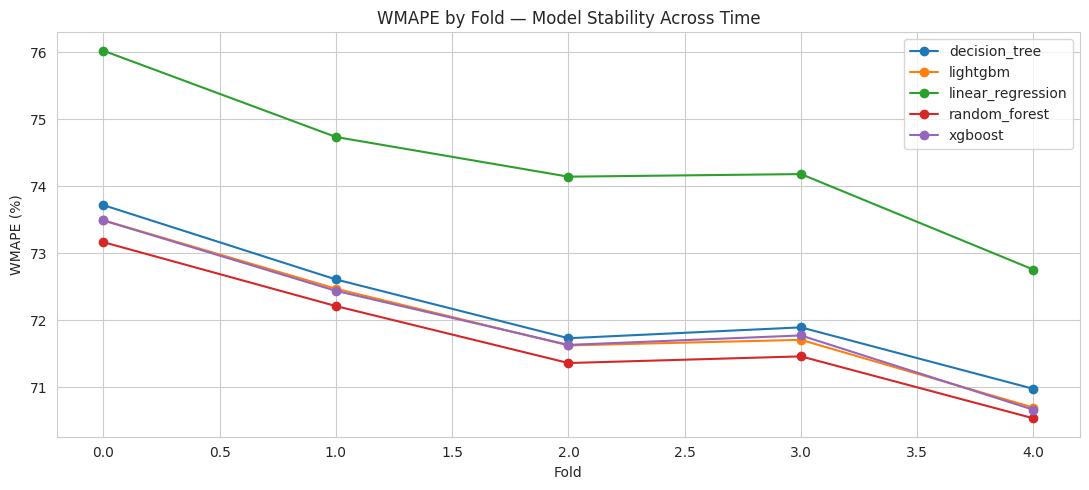

model,decision_tree,lightgbm,linear_regression,random_forest,xgboost
fold,,,,,
0,73.72,73.49,76.03,73.17,73.49
1,72.61,72.47,74.74,72.21,72.44
2,71.73,71.63,74.15,71.36,71.63
3,71.90,71.71,74.18,71.46,71.78
4,70.98,70.70,72.76,70.54,70.66


In [75]:
ml_results_df = pd.read_csv(CHECKPOINT_METRICS_PATH)
pivot_wmape = ml_results_df.pivot(index='fold', columns='model', values='wmape') * 100

plt.figure(figsize=(11, 5))
for col in pivot_wmape.columns:
    plt.plot(pivot_wmape.index, pivot_wmape[col], marker='o', label=col)
plt.title('WMAPE by Fold — Model Stability Across Time')
plt.xlabel('Fold')
plt.ylabel('WMAPE (%)')
plt.legend()
plt.tight_layout()
plt.show()

pivot_wmape.round(2)

## Average Performance Summary and Validation Strategy

In [76]:
avg_summary = ml_results_df.groupby('model')[['mae', 'rmse', 'wmape']].agg(['mean', 'std']).round(4)
avg_summary

mae            rmse           wmape        
                     mean     std    mean     std    mean     std
model                                                            
decision_tree      0.9180  0.0322  1.8397  0.0266  0.7219  0.0104
lightgbm           0.9156  0.0317  1.8145  0.0256  0.7200  0.0105
linear_regression  0.9457  0.0314  1.8933  0.0110  0.7437  0.0118
random_forest      0.9124  0.0323  1.8160  0.0277  0.7175  0.0099
xgboost            0.9156  0.0317  1.8131  0.0253  0.7200  0.0105

In [77]:
print("""
Production validation strategy recommendation:
TimeSeriesSplit walk-forward validation is preferred over a single train/test split because:
1. It estimates performance across multiple realistic re-forecasting windows, not just one.
2. It surfaces stability/variance across folds (Section 6), not just a point estimate.
3. It directly simulates production retraining on an expanding window.
A single split is acceptable only for quick prototyping, never for a final recommendation.
""")


Production validation strategy recommendation:
TimeSeriesSplit walk-forward validation is preferred over a single train/test split because:
1. It estimates performance across multiple realistic re-forecasting windows, not just one.
2. It surfaces stability/variance across folds (Section 6), not just a point estimate.
3. It directly simulates production retraining on an expanding window.
A single split is acceptable only for quick prototyping, never for a final recommendation.



## Feature Importance Preview

Lowest average WMAPE: random_forest


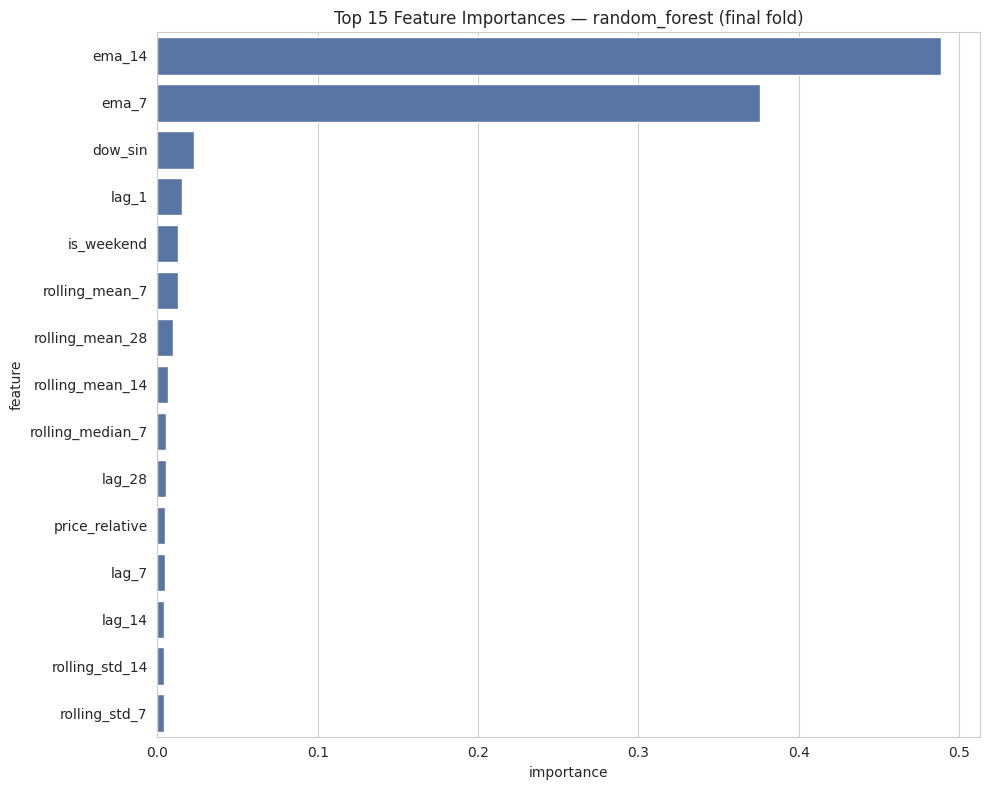

130

In [78]:
best_model_name = avg_summary[('wmape', 'mean')].idxmin()
best_model = joblib.load(f"{MODELS_DIR}/{best_model_name}_final_fold.pkl")
print(f"Lowest average WMAPE: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': FEATURE_COLS, 'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#4C72B0')
    plt.title(f'Top 15 Feature Importances — {best_model_name} (final fold)')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no .feature_importances_ — permutation/coefficient importance in Item #15.")

del best_model
gc.collect()

## Finalize Outputs

In [79]:
expected = {(f[0], name) for f in fold_boundaries for name in MODEL_NAMES}
missing = expected - completed

if missing:
    print(f"WARNING: {len(missing)} (fold, model) pairs incomplete: {sorted(missing)}")
    print("Re-run Section 5 to finish before finalizing.")
else:
    FINAL_OUT_PATH = f"{PROCESSED_DIR}/ml_model_metrics.csv"
    ml_results_df.to_csv(FINAL_OUT_PATH, index=False)
    print("All 25 (fold, model) results complete. Saved final ml_model_metrics.csv —", ml_results_df.shape)

print("Models saved in:", MODELS_DIR)
print(os.listdir(MODELS_DIR))

All 25 (fold, model) results complete. Saved final ml_model_metrics.csv — (25, 7)
Models saved in: /content/drive/MyDrive/Supply_Chain_Demand_Forecasting/models
['linear_regression_final_fold.pkl', 'decision_tree_final_fold.pkl', 'random_forest_final_fold.pkl', 'xgboost_final_fold.pkl', 'lightgbm_final_fold.pkl']


In [80]:
del df, ml_results_df
gc.collect()

5195

## Baseline vs. ML Model Comparison (Skill Score)

In [81]:
BASELINE_PATH = f"{PROCESSED_DIR}/baseline_metrics.csv"
ML_METRICS_PATH = f"{PROCESSED_DIR}/ml_model_metrics.csv"

baseline_df = pd.read_csv(BASELINE_PATH)
ml_df = pd.read_csv(ML_METRICS_PATH)

print("Baseline results loaded:", baseline_df.shape)
print("ML model results loaded:", ml_df.shape)

baseline_df.head()

Baseline results loaded: (10, 7)
ML model results loaded: (25, 7)


,label,mae,rmse,wmape,n_rows,fold,model
0,Fold 0 — Naive,1.046241,2.372359,0.882316,170650,0,naive
1,Fold 0 — Seasonal Naive,1.075822,2.501285,0.907262,170650,0,seasonal_naive
2,Fold 1 — Naive,1.091720,2.499781,0.872750,170704,1,naive
3,Fold 1 — Seasonal Naive,1.116037,2.537790,0.892190,170704,1,seasonal_naive
4,Fold 2 — Naive,1.111198,2.443391,0.870689,170732,2,naive


In [82]:
# Combine into one long-format table: one row per (fold, model), model names distinguish
# baseline vs. ML so everything downstream can be grouped identically.
combined_df = pd.concat([baseline_df, ml_df], ignore_index=True, sort=False)

print("Models present:", sorted(combined_df['model'].unique()))
combined_df.head()

Models present: ['decision_tree', 'lightgbm', 'linear_regression', 'naive', 'random_forest', 'seasonal_naive', 'xgboost']


,label,mae,rmse,wmape,n_rows,fold,model,n_train,n_test
0,Fold 0 — Naive,1.046241,2.372359,0.882316,170650.0,0,naive,NaN,NaN
1,Fold 0 — Seasonal Naive,1.075822,2.501285,0.907262,170650.0,0,seasonal_naive,NaN,NaN
2,Fold 1 — Naive,1.091720,2.499781,0.872750,170704.0,1,naive,NaN,NaN
3,Fold 1 — Seasonal Naive,1.116037,2.537790,0.892190,170704.0,1,seasonal_naive,NaN,NaN
4,Fold 2 — Naive,1.111198,2.443391,0.870689,170732.0,2,naive,NaN,NaN


## Average Performance Comparison Table

In [83]:
summary = (
    combined_df.groupby('model')[['mae', 'rmse', 'wmape']]
    .mean()
    .rename(columns={'mae': 'avg_mae', 'rmse': 'avg_rmse', 'wmape': 'avg_wmape'})
)
summary['avg_wmape_pct'] = (summary['avg_wmape'] * 100).round(2)

# Identify the best baseline (lowest WMAPE among naive / seasonal_naive) as the reference point
BASELINE_MODELS = ['naive', 'seasonal_naive']
best_baseline_name = summary.loc[BASELINE_MODELS, 'avg_wmape'].idxmin()
best_baseline_wmape = summary.loc[best_baseline_name, 'avg_wmape']

print(f"Best baseline: {best_baseline_name} (avg WMAPE = {best_baseline_wmape*100:.2f}%)")

# Difference from the best baseline -- absolute (percentage points) and relative (% improvement)
summary['wmape_diff_pp'] = ((summary['avg_wmape'] - best_baseline_wmape) * 100).round(2)
summary['pct_improvement_vs_baseline'] = (
    (best_baseline_wmape - summary['avg_wmape']) / best_baseline_wmape * 100
).round(2)
summary['beats_baseline'] = summary['avg_wmape'] < best_baseline_wmape

comparison_table = summary[
    ['avg_mae', 'avg_rmse', 'avg_wmape_pct', 'wmape_diff_pp', 'pct_improvement_vs_baseline', 'beats_baseline']
].sort_values('avg_wmape_pct')

comparison_table.round(4)

Best baseline: naive (avg WMAPE = 87.12%)


,avg_mae,avg_rmse,avg_wmape_pct,wmape_diff_pp,pct_improvement_vs_baseline,beats_baseline
model,,,,,,
random_forest,0.9124,1.8160,71.75,-15.37,17.65,True
lightgbm,0.9156,1.8145,72.00,-15.12,17.36,True
xgboost,0.9156,1.8131,72.00,-15.12,17.36,True
decision_tree,0.9180,1.8397,72.19,-14.93,17.14,True
linear_regression,0.9457,1.8933,74.37,-12.75,14.64,True
naive,1.1081,2.4556,87.12,0.00,0.00,False
seasonal_naive,1.1286,2.4995,88.75,1.62,-1.86,False


## Best-Performing Model Highlight

In [84]:
best_overall = comparison_table.index[0]
best_overall_wmape = comparison_table.loc[best_overall, 'avg_wmape_pct']
best_overall_improvement = comparison_table.loc[best_overall, 'pct_improvement_vs_baseline']

print(f"Best-performing model overall: {best_overall}")
print(f"Average WMAPE: {best_overall_wmape}%")
print(f"Improvement over best baseline ({best_baseline_name}): {best_overall_improvement}% relative reduction in error")

Best-performing model overall: random_forest
Average WMAPE: 71.75%
Improvement over best baseline (naive): 17.65% relative reduction in error


## Visualization: Baseline vs. ML Models

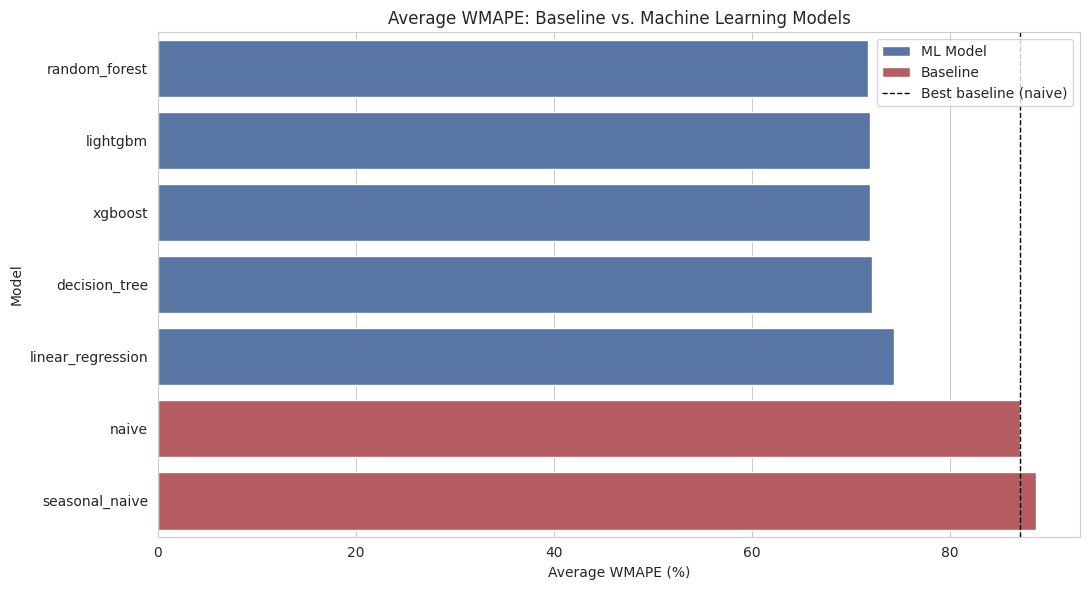

In [85]:
plot_df = comparison_table.reset_index().rename(columns={'index': 'model'})
plot_df['category'] = plot_df['model'].apply(lambda m: 'Baseline' if m in BASELINE_MODELS else 'ML Model')

plt.figure(figsize=(11, 6))
palette = {'Baseline': '#C44E52', 'ML Model': '#4C72B0'}
bars = sns.barplot(
    data=plot_df.sort_values('avg_wmape_pct'),
    x='avg_wmape_pct', y='model', hue='category', palette=palette, dodge=False
)
plt.axvline(best_baseline_wmape * 100, color='black', linestyle='--', linewidth=1,
            label=f'Best baseline ({best_baseline_name})')
plt.title('Average WMAPE: Baseline vs. Machine Learning Models')
plt.xlabel('Average WMAPE (%)')
plt.ylabel('Model')
plt.legend(title='')
plt.tight_layout()
plt.show()

## Interpretation

In [86]:
n_ml_beating_baseline = plot_df[(plot_df['category'] == 'ML Model') & (plot_df['beats_baseline'])].shape[0]
n_ml_total = plot_df[plot_df['category'] == 'ML Model'].shape[0]

print(f"{n_ml_beating_baseline} of {n_ml_total} ML models beat the best baseline ({best_baseline_name}).")
print(f"Best overall model: {best_overall} — {best_overall_improvement}% relative WMAPE improvement.")

5 of 5 ML models beat the best baseline (naive).
Best overall model: random_forest — 17.65% relative WMAPE improvement.


## Key Takeaways
### Classical machine learning models were trained using engineered time-series features such as lag variables and rolling statistics rather than raw sales values.
### TimeSeriesSplit (walk-forward validation) was used to evaluate models, ensuring that future observations were never used to predict the past and preventing data leakage.
### Multiple evaluation metrics (MAE, RMSE, and WMAPE) were used to compare model performance from different perspectives.
### Fold-by-fold evaluation measured the stability and consistency of each model across different time periods instead of relying on a single train-test split.
### The best-performing model will serve as the primary forecasting model for later optimization, interpretation, and deployment.
### All five machine learning models outperformed the best baseline (naive) by 14.6–17.7% in relative WMAPE, with Random Forest achieving the strongest result (17.65% improvement), confirming that the engineered lag, rolling, and calendar/event features add genuine predictive value beyond a simple "yesterday repeats" forecast.


## Business Insight

### Machine learning models captured demand patterns that the baseline methods could not. All five ML models outperformed the best baseline (Naive Forecast, 87.12% WMAPE) by double-digit relative margins, with Random Forest achieving the best performance (71.75% WMAPE, a 17.65% improvement). Interestingly, the Seasonal Naive model performed slightly worse than the plain Naive model (88.75% vs. 87.12%), suggesting that at the individual store-item-day level, the previous day's demand was a more reliable predictor than demand from the same weekday in the previous week. This highlights the difference between aggregate seasonal trends and forecasting individual product demand. Based on these results, Random Forest is the recommended model for the next stage of the project (feature importance, explainability, and error analysis), subject to its consistent performance across validation folds.